In [29]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import VAE.architecture
from VAE.loss import PerceptualLoss
import os
from sklearn.manifold import TSNE
import wandb

In [ ]:
# class Derma64Dataset(Dataset):
#     def __init__(self, images_path, labels_path=None, transform=None):
#         self.images = np.load(images_path)       # shape: [N, 64, 64, 3]
#         self.labels = np.load(labels_path) if labels_path else None
#         self.transform = transform

#     def __len__(self):
#         return len(self.images)

#     def __getitem__(self, idx):
#         img = self.images[idx].astype(np.float32) / 255.0  # normalize to 0–1
#         img = torch.from_numpy(img).permute(2,0,1)         # HWC -> CHW
#         if self.transform:
#             img = self.transform(img)
#         if self.labels is not None:
#             label = int(self.labels[idx])
#             return img, label
#         return img

In [30]:

class Derma64Dataset(Dataset):
    def __init__(self, images_path, labels_path=None, augment=False):
        self.images  = np.load(images_path)          # [N, 64, 64, 3]
        self.labels  = np.load(labels_path) if labels_path else None
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32) / 255.0
        img = torch.from_numpy(img).permute(2, 0, 1)   # HWC → CHW

        if self.augment:
            # Simple augmentations without torchvision dependency
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[2])          # horizontal flip
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[1])          # vertical flip

        if self.labels is not None:
            return img, int(self.labels[idx].item())
        return img

In [31]:
BATCH_SIZE = 128

train_dataset = Derma64Dataset("data/train_images.npy", "data/train_labels.npy")
print(len(train_dataset))
val_dataset = Derma64Dataset("data/val_images.npy", "data/val_labels.npy")
test_dataset = Derma64Dataset("data/test_images.npy", "data/test_labels.npy")
print(len(val_dataset))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

7007
1003


In [18]:
np.unique(val_dataset.labels)


array([0, 1, 2, 3, 4, 5, 6], dtype=uint8)

My attempts at doing VAE with simple conv layers failed regardless of hyperparams like epoch num, stride, padding, layers, latent_dim, and etc.

The failure was that the reconstructed images were basically blurred, averaged with no real feature remaining.



Here, I will attempt to add resnet layers with more batch normalization.

Resnet layers with laten_dim = 64 did not produce great result (60 epochs). I increased the laten_dim to 256, 512 and the results were better. Gradient kept getting unstable so I used a gradient clipper. Also, since KL was getting too small in the begining and did not allow the mse to grow smaller afterwards, I made the beta variable (beta * kl in loss) to start very small and slowly grow bigger. The results are not terrible and I believe the actual good results could be achieved with epoch around 100 for latent_dim = 512. But for now, I will keep working on my makinga a Tutor based on the latent_dim = 256 and epoch 100, if it's not good enough, I will change to 512 dimension

In [4]:
from VAE.architecture import Encoder, Decoder, VAE

LATENT_DIM = 256
EPOCHS = 100
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET_SHAPE = (3, 64, 64)

encoder_layer_list = [
    (1, 32),
    (1, 64),
    (1, 128),
]

decoder_layer_list = [
    (1, 128),
    (1, 64),
    (1, 32),
]


run the following cell if you want to load a saved model, otherwise skip

In [5]:
def load_model(model, path):
    state_dict = torch.load(os.path.join(path, "VAE_model.pt"))
    model.load_state_dict(state_dict, strict=False)
    model.basis = torch.load(os.path.join(path, "vae_basis.pt"))
    return model

encoder1 = Encoder(latent_dim=LATENT_DIM, layer_list=encoder_layer_list)
decoder1 = Decoder(target_shape=TARGET_SHAPE, latend_dim=LATENT_DIM, layer_list=decoder_layer_list)
model_saved = VAE(encoder=encoder1, decoder=decoder1, laten_dim=LATENT_DIM, input_dim=TARGET_SHAPE).to(DEVICE)

model_saved = load_model(model_saved, "val_model")

Run the following cell if you want to train the vae. otherwise, skip

/tmp/ipykernel_24809/1387475648.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


  ✓ Saved best model (val_loss=13314.8578)
Epoch 1/100 | Train Loss: 30980.5481 (recon=30980.5481, kl=242.4023) | Val Loss: 13314.8578 (recon=13301.9175, kl=12.9402)
Epoch 2/100 | Train Loss: 9581.2476 (recon=9580.9638, kl=11.3544) | Val Loss: 40395.3833 (recon=40379.8232, kl=15.5603)
  ✓ Saved best model (val_loss=4525.0410)
Epoch 3/100 | Train Loss: 6381.3135 (recon=6380.5499, kl=15.2716) | Val Loss: 4525.0410 (recon=4511.6707, kl=13.3703)
  ✓ Saved best model (val_loss=6330.5867)
Epoch 4/100 | Train Loss: 4439.5558 (recon=4438.4393, kl=14.8865) | Val Loss: 6330.5867 (recon=6315.3915, kl=15.1952)
  ✓ Saved best model (val_loss=3312.3546)
Epoch 5/100 | Train Loss: 3965.8903 (recon=3964.5571, kl=13.3327) | Val Loss: 3312.3546 (recon=3300.1774, kl=12.1772)
  ✓ Saved best model (val_loss=3566.2243)
Epoch 6/100 | Train Loss: 3331.1238 (recon=3329.4780, kl=13.1664) | Val Loss: 3566.2243 (recon=3552.6693, kl=13.5550)
  ✓ Saved best model (val_loss=3077.0431)
Epoch 7/100 | Train Loss: 3219.6

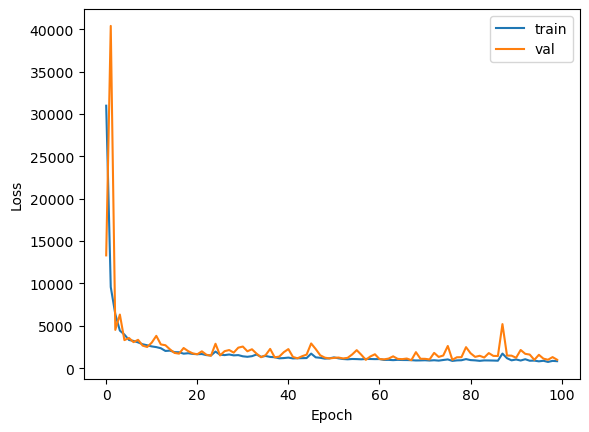

In [ ]:

encoder = Encoder(latent_dim=LATENT_DIM, layer_list=encoder_layer_list)
decoder = Decoder(target_shape=TARGET_SHAPE, latend_dim=LATENT_DIM, layer_list=decoder_layer_list)
model = VAE(encoder=encoder, decoder=decoder, laten_dim=LATENT_DIM, input_dim=TARGET_SHAPE).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LR)
perceptual = PerceptualLoss().to(DEVICE)
def vae_loss_p(x, x_recon, z_mean, z_log_var, beta=1.0, lam=0.1):
    recon_loss = F.mse_loss(x_recon, x, reduction="sum")
    perc_loss = perceptual(x, x_recon)
    kl_loss = -0.5 * torch.mean(1 + z_log_var - z_mean.pow(2) - z_log_var.exp())
    return recon_loss + lam * perc_loss + beta * kl_loss, recon_loss, kl_loss




def vae_loss(x, x_recon, z_mean, z_log_var, beta=1.0):
    recon_loss = F.mse_loss(x_recon, x, reduction="sum")
    # KL divergence: -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kl_loss = -0.5 * torch.mean(1 + z_log_var - z_mean.pow(2) - z_log_var.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


def run_epoch(model, loader, optimizer, device, train=True, beta=1.0):
    model.train() if train else model.eval()
    total_loss, total_recon, total_kl = 0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            imgs = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)

            x_recon, z, _, z_mean, z_log_var = model(imgs)
            #z_mean, z_log_var = model.encoder(imgs)  
            loss, recon, kl = vae_loss(imgs, x_recon, z_mean, z_log_var, beta)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
                optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

    n = len(loader)
    return total_loss / n, total_recon / n, total_kl / n



train_losses, val_losses = [], []
best_loss = float("inf")
for epoch in range(EPOCHS):
    beta = min(1.0, epoch / 40)
    train_loss, train_recon, train_kl = run_epoch(model, train_loader, optimizer, DEVICE, train=True, beta=beta)
    val_loss, val_recon, val_kl = run_epoch(model, val_loader, optimizer, DEVICE, train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    l = val_loss + train_loss
    if l < best_loss:
        best_loss = l
        model.save_model("val_model")
        print(f"  ✓ Saved best model (val_loss={val_loss:.4f})")

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} (recon={train_recon:.4f}, kl={train_kl:.4f}) | "
          f"Val Loss: {val_loss:.4f} (recon={val_recon:.4f}, kl={val_kl:.4f})")
#model.save_model("")

# --- Plot ---
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("loss_curve.png")
plt.show()

/tmp/ipykernel_61541/1387475648.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


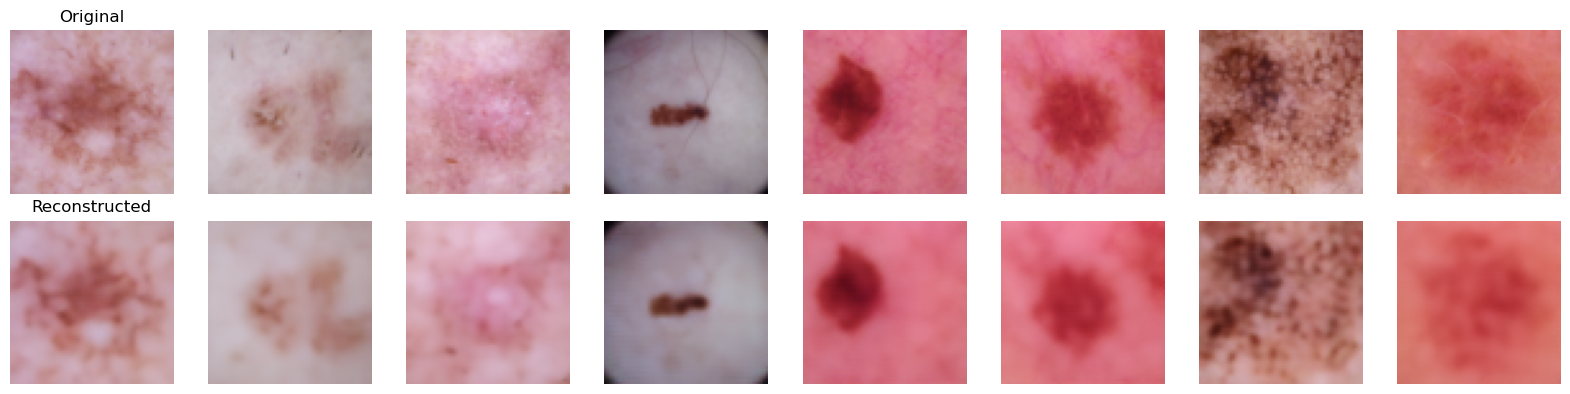

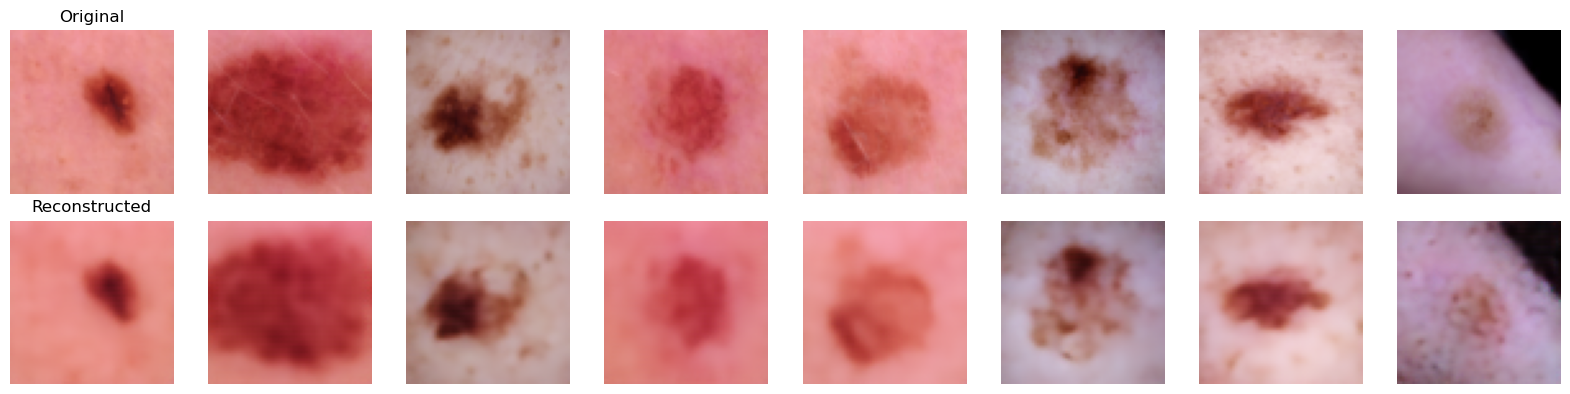

In [6]:
def visualize_reconstructions(model, loader, device, n=8):
    model.eval()
    batch = next(iter(loader))
    imgs = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
    imgs = imgs[:n]

    with torch.no_grad():
        x_recon, _, _ ,_,_= model(imgs)

    fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))
    for i in range(n):
        # Original
        axes[0, i].imshow(imgs[i].cpu().permute(1, 2, 0).clamp(0, 1))
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original")

        # Reconstructed
        axes[1, i].imshow(x_recon[i].cpu().permute(1, 2, 0).clamp(0, 1))
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_title("Reconstructed")

    plt.tight_layout()
    plt.savefig("reconstructions1.png")
    plt.show()

# Call after training:
visualize_reconstructions(model_saved, train_loader, DEVICE)
visualize_reconstructions(model_saved, val_loader, DEVICE)

In [12]:
def sample_new_lesions(model, n=16):
    model.eval()
    with torch.no_grad():
        # Sample from standard normal latent space
        z = torch.randn(n, model.latent_dim).to(next(model.parameters()).device)
        samples = model.decoder(z).cpu()  # shape: [n, 3, 64, 64]

    # Plot
    import torchvision
    grid = torchvision.utils.make_grid(samples, nrow=4)
    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")
    plt.title("Synthetic Lesions")
    plt.show()

In [15]:
def interpolate_lesions(model, loader, idx1=0, idx2=1, steps=8):
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(loader))
        img1, img2 = images[idx1].unsqueeze(0), images[idx2].unsqueeze(0)
        
        # Encode to latent space
        z_mean, z_log_var = model.encoder(img1)
        z1 = torch.distributions.Normal(z_mean, torch.exp(0.5 * z_log_var) + 1e-6).rsample()
        z_mean2, z_log_var2 = model.encoder(img2)
        z2 = torch.distributions.Normal(z_mean2, torch.exp(0.5 * z_log_var2) + 1e-6).rsample()
        
        # Linear interpolation
        interpolated = []
        for alpha in torch.linspace(0,1,steps):
            z = (1-alpha)*z1 + alpha*z2
            recon = model.decoder(z)
            interpolated.append(recon.cpu())
        
        interpolated = torch.cat(interpolated, dim=0)
    
    # Plot
    import torchvision
    grid = torchvision.utils.make_grid(interpolated, nrow=steps)
    plt.figure(figsize=(steps,2))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")
    plt.title("Latent Interpolation")
    plt.show()

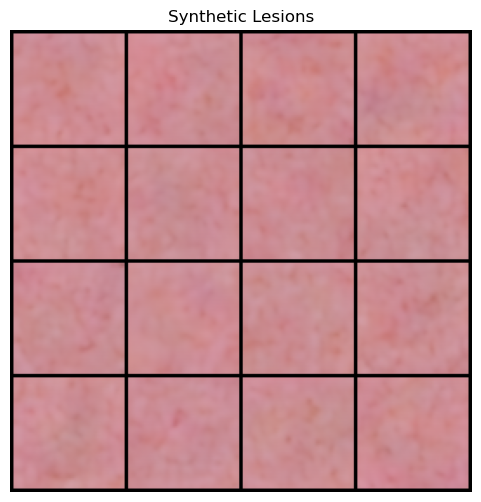

/tmp/ipykernel_61541/1387475648.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


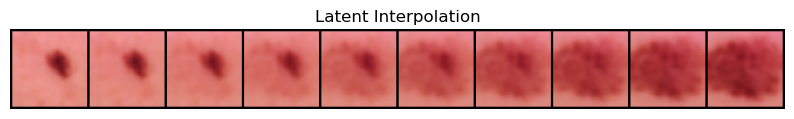

In [16]:
# Sample 4 random lesions
sample_new_lesions(model_saved, n=16)

# Interpolate between first two images in validation set
interpolate_lesions(model_saved, val_loader, idx1=0, idx2=1, steps=10)

Now let's train a classifier that classifies the lesions

In [32]:
from derma_cnn import DermaCNN, train_one_epoch, evaluate

In [33]:
BATCH_SIZE   = 128
EPOCHS       = 20
LR           = 1e-3
NUM_CLASSES  = 7        # ← adjust to your dataset (HAM10000 = 7)
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"


In [34]:

print(f"Device: {DEVICE}")
# Datasets & loaders
train_ds = Derma64Dataset("data/train_images.npy", "data/train_labels.npy", augment=True)
val_ds   = Derma64Dataset("data/val_images.npy",   "data/val_labels.npy")
test_ds  = Derma64Dataset("data/test_images.npy",  "data/test_labels.npy")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# Model
model     = DermaCNN(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}\n")

# Training loop
best_val_acc = 0.0
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    marker = " ← best" if val_acc > best_val_acc else ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_derma_cnn.pt")

    print(
        f"Epoch {epoch:02d}/{EPOCHS}  "
        f"train_loss={train_loss:.4f}  train_acc={train_acc:.3f}  "
        f"val_loss={val_loss:.4f}  val_acc={val_acc:.3f}{marker}"
    )

# Final test evaluation
print("\nLoading best model for test evaluation...")
model.load_state_dict(torch.load("best_derma_cnn.pt", map_location=DEVICE))
test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.3f}")




Device: cpu
Train: 7007 | Val: 1003 | Test: 2005

Model parameters: 322,727



Epoch 01/20  train_loss=0.9651  train_acc=0.660  val_loss=0.8616  val_acc=0.679 ← best
Epoch 02/20  train_loss=0.8303  train_acc=0.688  val_loss=0.8954  val_acc=0.646
Epoch 03/20  train_loss=0.7916  train_acc=0.704  val_loss=1.3433  val_acc=0.437
Epoch 04/20  train_loss=0.7625  train_acc=0.715  val_loss=1.0004  val_acc=0.634
Epoch 05/20  train_loss=0.7531  train_acc=0.723  val_loss=0.7240  val_acc=0.739 ← best
Epoch 06/20  train_loss=0.7221  train_acc=0.730  val_loss=0.9272  val_acc=0.678
Epoch 07/20  train_loss=0.7065  train_acc=0.741  val_loss=0.7970  val_acc=0.721
Epoch 08/20  train_loss=0.6842  train_acc=0.748  val_loss=0.9785  val_acc=0.726
Epoch 09/20  train_loss=0.6820  train_acc=0.749  val_loss=0.7176  val_acc=0.735
Epoch 10/20  train_loss=0.6581  train_acc=0.757  val_loss=0.6983  val_acc=0.741 ← best
Epoch 11/20  train_loss=0.6520  train_acc=0.754  val_loss=0.6783  val_acc=0.751 ← best
Epoch 12/20  train_loss=0.6390  train_acc=0.763  val_loss=0.7386  val_acc=0.727
Epoch 13/20 

Model loaded.
Dataset size: 1003
  [!] Only 0 correct samples found for 'Dermatofibroma'
Saved → results_grid.png


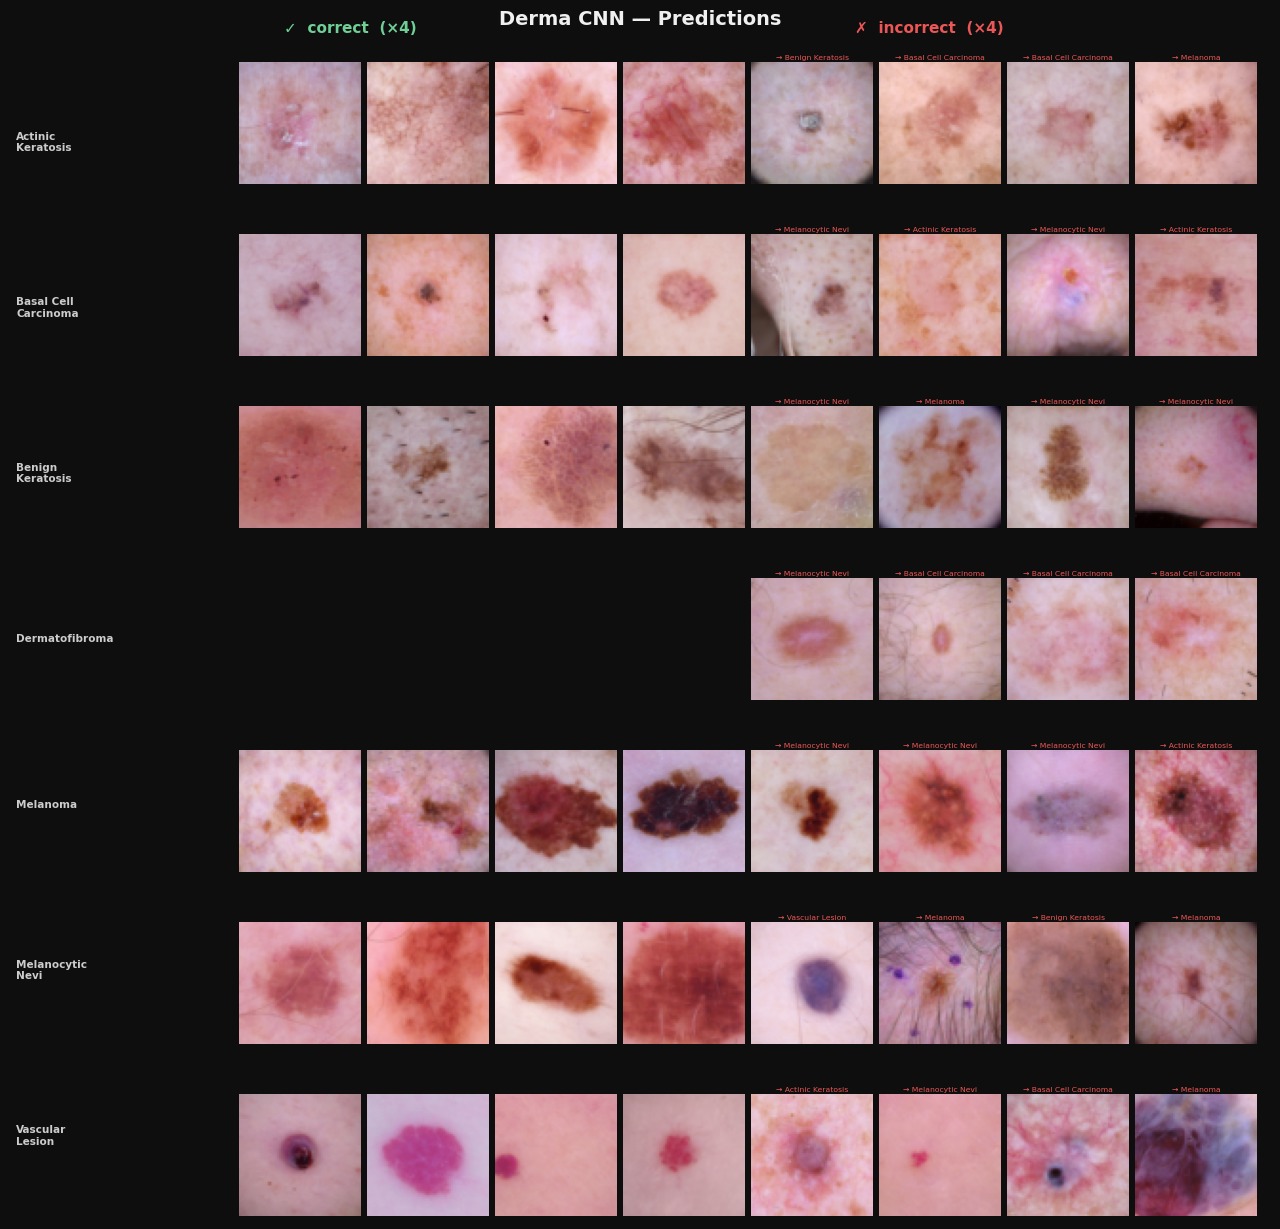

In [28]:
"""
visualize_results.py — Show correct & incorrect predictions per class.

Usage:
    python visualize_results.py

Saves: results_grid.png
"""

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from derma_cnn import DermaCNN, Derma64Dataset
from torch.utils.data import DataLoader

# ── HAM10000 class names (adjust if your labels differ) ──────────────────────
CLASS_NAMES = {
    0: "Actinic\nKeratosis",
    1: "Basal Cell\nCarcinoma",
    2: "Benign\nKeratosis",
    3: "Dermatofibroma",
    4: "Melanoma",
    5: "Melanocytic\nNevi",
    6: "Vascular\nLesion",
}
SAMPLES_PER_CLASS = 4   # how many correct + incorrect examples to show per row

# ─────────────────────────────────────────────────────────────────────────────

def collect_samples(model, dataset, n=SAMPLES_PER_CLASS):
    """Return dicts mapping class → list of (img_np, pred) for correct/wrong."""
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    correct = {c: [] for c in range(NUM_CLASSES)}
    wrong   = {c: [] for c in range(NUM_CLASSES)}

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
            for img, true, pred in zip(imgs, labels, preds):
                true, pred = true.item(), pred.item()
                img_np = img.permute(1, 2, 0).numpy()   # CHW → HWC
                if true == pred and len(correct[true]) < n:
                    correct[true].append((img_np, pred))
                elif true != pred and len(wrong[true]) < n:
                    wrong[true].append((img_np, pred))
            if all(len(correct[c]) == n and len(wrong[c]) == n
                   for c in range(NUM_CLASSES)):
                break

    return correct, wrong


def plot_grid(correct, wrong):
    n      = SAMPLES_PER_CLASS
    nclass = NUM_CLASSES
    cols   = n * 2 + 1          # correct cols | spacer | wrong cols
    rows   = nclass

    fig = plt.figure(figsize=(cols * 1.4, rows * 1.6 + 1.2), facecolor="#0e0e0e")
    fig.suptitle("Derma CNN — Predictions", color="#f0f0f0",
                 fontsize=14, fontweight="bold", y=0.995)

    # Column headers
    header_ax = fig.add_axes([0, 0.965, 1, 0.03])
    header_ax.axis("off")
    header_ax.text(0.27, 0.5, f"✓  correct  (×{n})",
                   ha="center", va="center", color="#6fcf97",
                   fontsize=11, fontweight="bold")
    header_ax.text(0.73, 0.5, f"✗  incorrect  (×{n})",
                   ha="center", va="center", color="#eb5757",
                   fontsize=11, fontweight="bold")

    gs = fig.add_gridspec(rows, cols,
                          left=0.08, right=0.99,
                          top=0.955, bottom=0.02,
                          wspace=0.05, hspace=0.35)

    for row, cls in enumerate(range(nclass)):
        # Class label on the left
        label_ax = fig.add_subplot(gs[row, 0])
        label_ax.axis("off")
        # invisible — we use fig.text for precise placement
        y_pos = 1 - (row + 0.5) / rows
        fig.text(0.005, 0.02 + (rows - row - 0.5) / rows * 0.935,
                 CLASS_NAMES.get(cls, f"Class {cls}"),
                 ha="left", va="center", color="#cccccc",
                 fontsize=7.5, fontweight="bold")

        # Correct samples (cols 1..n)
        for i, (img, pred) in enumerate(correct[cls][:n]):
            ax = fig.add_subplot(gs[row, i + 1])
            ax.imshow(np.clip(img, 0, 1))
            ax.axis("off")
            for spine in ax.spines.values():
                spine.set_edgecolor("#6fcf97")
                spine.set_linewidth(1.5)
                spine.set_visible(True)

        # Incorrect samples (cols n+1..2n, skip middle spacer col)
        for i, (img, pred) in enumerate(wrong[cls][:n]):
            ax = fig.add_subplot(gs[row, i + n + 1])
            ax.imshow(np.clip(img, 0, 1))
            ax.axis("off")
            pred_name = CLASS_NAMES.get(pred, str(pred)).replace("\n", " ")
            ax.set_title(f"→ {pred_name}", fontsize=5.5,
                         color="#eb5757", pad=2)
            for spine in ax.spines.values():
                spine.set_edgecolor("#eb5757")
                spine.set_linewidth(1.5)
                spine.set_visible(True)

    plt.savefig("results_grid.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print("Saved → results_grid.png")
    plt.show()



model = DermaCNN(num_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load("best_derma_cnn.pt", map_location=DEVICE))
print("Model loaded.")

# Load val set (or swap for test_images/test_labels)
dataset = Derma64Dataset("data/val_images.npy", "data/val_labels.npy")
print(f"Dataset size: {len(dataset)}")

correct, wrong = collect_samples(model, dataset)

# Warn if not enough samples found for some class
for c in range(NUM_CLASSES):
    name = CLASS_NAMES.get(c, str(c)).replace("\n", " ")
    if len(correct[c]) < SAMPLES_PER_CLASS:
        print(f"  [!] Only {len(correct[c])} correct samples found for '{name}'")
    if len(wrong[c]) < SAMPLES_PER_CLASS:
        print(f"  [!] Only {len(wrong[c])} incorrect samples found for '{name}'")

plot_grid(correct, wrong)


